# GPN-Star demo

Use the published vertebrate GPN-Star checkpoint to inspect alignment-aware
nucleotide probabilities, raw log-likelihood ratios, and the existing mutation-rate
calibration example. This notebook uses only the tiny checked-in 128 bp alignment
fixture; it never downloads a whole-genome MSA.

## Setup

In [ ]:
!pip install --quiet "gpn[inference]" matplotlib seaborn

In [1]:
from hashlib import sha256
from importlib.metadata import version
from pathlib import Path
from urllib.request import urlretrieve

from gpn import register_auto_classes
from gpn.data import Tokenizer
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from transformers import AutoModelForMaskedLM

register_auto_classes("star")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"gpn={version('gpn')}, transformers={version('transformers')}, "
    f"torch={version('torch')}, device={DEVICE}"
)

gpn=0.9.0a1, transformers=5.15.0, torch=2.13.0+cpu, device=cpu


In [2]:
MODEL_ID = "songlab/gpn-star-hg38-v100-200m"
MODEL_REVISION = "0c949f132d35619a3eb188b402848c998a3313ae"
print(f"{MODEL_ID} @ {MODEL_REVISION}")

songlab/gpn-star-hg38-v100-200m @ 0c949f132d35619a3eb188b402848c998a3313ae


## Tiny alignment fixture

The original example locus is the zero-based, half-open hg38 interval
`chr6:31575665-31575793`. The fixture contains the same target sequence and the 99
source-species columns expected by the vertebrate checkpoint.

[Open the locus in the UCSC Genome Browser](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg38&position=chr6%3A31575665%2D31575793)

In [3]:
FIXTURE_PATH = Path("hg38_chr6_31575665_31575793_multiz100way.npz")
FIXTURE_COMMIT = "7553aa4469c32404f1c595d33f4d165de8dae978"
FIXTURE_URL = (
    f"https://raw.githubusercontent.com/songlab-cal/gpn/{FIXTURE_COMMIT}/"
    "tests/fixtures/hg38_chr6_31575665_31575793_multiz100way.npz"
)
FIXTURE_SHA256 = "3e0a627626ce319932add04bd683d2151af7badfe3dc0e122f39c5e8492600c0"
if not FIXTURE_PATH.exists():
    urlretrieve(FIXTURE_URL, FIXTURE_PATH)
fixture_sha256 = sha256(FIXTURE_PATH.read_bytes()).hexdigest()
if fixture_sha256 != FIXTURE_SHA256:
    raise ValueError(f"Unexpected alignment fixture SHA-256: {fixture_sha256}")

In [4]:
with np.load(FIXTURE_PATH, allow_pickle=False) as fixture:
    alignment_tokens = fixture["gpn_star_v100_tokens"].astype(np.int64)

tokenizer = Tokenizer()
token_to_base = np.array(list(tokenizer.vocab), dtype="U1")
raw_alignment = token_to_base[alignment_tokens]
msa = torch.from_numpy(alignment_tokens).unsqueeze(0).to(DEVICE)
print(msa.shape)
raw_alignment[:, 0]

torch.Size([1, 128, 100])


array(['A', 'C', 'A', 'A', 'G', 'C', 'T', 'G', 'C', 'C', 'A', 'G', 'G',
       'C', 'A', 'G', 'G', 'T', 'T', 'C', 'T', 'C', 'T', 'T', 'C', 'C',
       'T', 'C', 'T', 'C', 'A', 'C', 'A', 'T', 'A', 'C', 'T', 'G', 'A',
       'C', 'C', 'C', 'A', 'C', 'G', 'G', 'C', 'T', 'C', 'C', 'A', 'C',
       'C', 'C', 'T', 'C', 'T', 'C', 'T', 'C', 'C', 'C', 'C', 'T', 'G',
       'G', 'A', 'A', 'A', 'G', 'G', 'A', 'C', 'A', 'C', 'C', 'A', 'T',
       'G', 'A', 'G', 'C', 'A', 'C', 'T', 'G', 'A', 'A', 'A', 'G', 'C',
       'A', 'T', 'G', 'A', 'T', 'C', 'C', 'G', 'G', 'G', 'A', 'C', 'G',
       'T', 'G', 'G', 'A', 'G', 'C', 'T', 'G', 'G', 'C', 'C', 'G', 'A',
       'G', 'G', 'A', 'G', 'G', 'C', 'G', 'C', 'T', 'C', 'C'], dtype='<U1')

## Masked nucleotide probabilities

In [5]:
model_for_mlm = AutoModelForMaskedLM.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION
).to(DEVICE).eval()

position = 76
print("model dtype:", next(model_for_mlm.parameters()).dtype)
print("Start codon:", "".join(raw_alignment[position : position + 3, 0]))
input_ids = msa[:, :, :1].clone()
input_ids[0, position, 0] = tokenizer.mask_token_id()

with torch.inference_mode():
    all_logits = model_for_mlm(
        input_ids=input_ids,
        source_ids=msa,
        target_species=torch.tensor([[0]], device=DEVICE),
    ).logits

nucleotides = list("ACGT")
nucleotide_ids = [tokenizer.vocab.index(base) for base in nucleotides]
logits = all_logits[0, position, 0, nucleotide_ids].cpu()
probabilities = torch.softmax(logits, dim=0).numpy()
pd.DataFrame(
    {"nucleotide": nucleotides, "logit": logits.numpy(), "probability": probabilities}
)

model dtype: torch.float32
Start codon: ATG


,nucleotide,logit,probability
0,A,7.706210,0.999677
1,C,-1.922049,0.000066
2,G,-0.691238,0.000225
3,T,-2.650750,0.000032


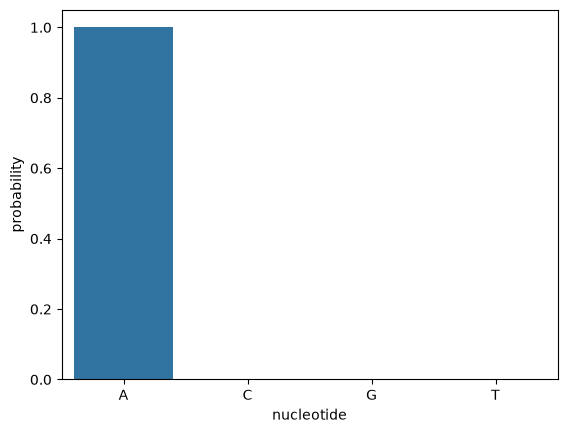

In [6]:
probability_frame = pd.DataFrame(
    {"nucleotide": nucleotides, "probability": probabilities}
)
sns.barplot(data=probability_frame, x="nucleotide", y="probability")
plt.show()

## Raw log-likelihood ratios

In [7]:
reference = raw_alignment[position, 0]
alternate_alleles = [base for base in nucleotides if base != reference]
reference_logit = logits[nucleotides.index(reference)]
raw_llrs = [
    logits[nucleotides.index(alternate)].item() - reference_logit.item()
    for alternate in alternate_alleles
]
llr_frame = pd.DataFrame(
    {
        "variant": [f"{reference}>{alternate}" for alternate in alternate_alleles],
        "alternate": alternate_alleles,
        "raw LLR": raw_llrs,
    }
)
llr_frame

,variant,alternate,raw LLR
0,A>C,C,-9.628258
1,A>G,G,-8.397448
2,A>T,T,-10.356960


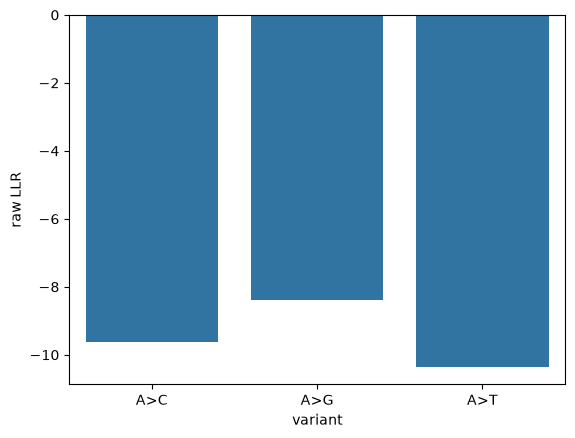

In [8]:
sns.barplot(data=llr_frame, x="variant", y="raw LLR")
plt.show()

## Mutation-rate calibration

The published calibration subtracts the neutral mean for the central
pentanucleotide and alternate allele. This is separate from the raw LLR emitted by
the maintained CLI.

In [9]:
context = "".join(raw_alignment[position - 2 : position + 3, 0])
calibration_path = hf_hub_download(
    MODEL_ID,
    "calibration_table/llr.parquet",
    revision=MODEL_REVISION,
)
calibration = pd.read_parquet(calibration_path)
llr_frame["pentanucleotide mutation"] = [
    f"{context}_{alternate}" for alternate in alternate_alleles
]
llr_frame = llr_frame.merge(
    calibration,
    left_on="pentanucleotide mutation",
    right_on="pentanuc_mut",
    how="left",
)
llr_frame["calibrated LLR"] = (
    llr_frame["raw LLR"] - llr_frame["llr_neutral_mean"]
)
llr_frame[["variant", "raw LLR", "llr_neutral_mean", "calibrated LLR"]]

,variant,raw LLR,llr_neutral_mean,calibrated LLR
0,A>C,-9.628258,-1.431537,-8.196722
1,A>G,-8.397448,-1.295980,-7.101467
2,A>T,-10.356960,-1.452028,-8.904932


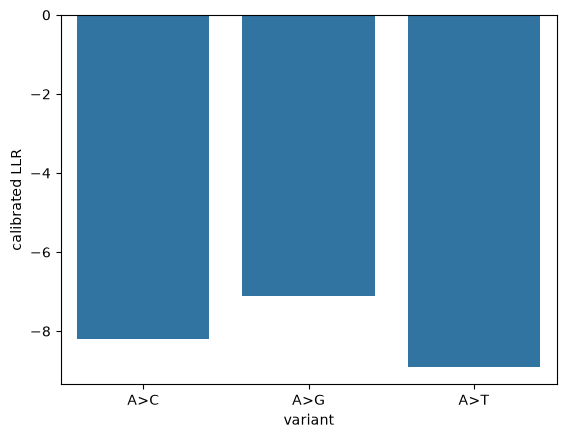

In [10]:
sns.barplot(data=llr_frame, x="variant", y="calibrated LLR")
plt.show()